In [1]:
import sys
!{sys.executable} -m pip install yolov5

In [2]:
import requests
import numpy as np
from PIL import Image
from io import BytesIO
import torch
import pandas as pd
import numpy as np
from torchvision.transforms import transforms
from tqdm import tqdm

from advsecurenet.computer_vision.object_detection.attacks.adversarial_patch_based.dpatch import DPatch


import cv2
import matplotlib
import matplotlib.pyplot as plt


plt.style.use('ggplot')
matplotlib.use( 'Agg' )
%matplotlib inline

/home/user/arutkiewicz/advsecurenet/code/advsecurenet_mp/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
COCO_INSTANCE_CATEGORY_NAMES = ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
        'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
        'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
        'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard',
        'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
        'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
        'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 
        'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 
        'teddy bear', 'hair drier', 'toothbrush']

def extract_predictions(predictions_, conf_thresh):
    # Get the predicted class
    predictions_class = [COCO_INSTANCE_CATEGORY_NAMES[i] for i in list(predictions_["labels"])]
    #  print("\npredicted classes:", predictions_class)
    if len(predictions_class) < 1:
        return [], [], []
    # Get the predicted bounding boxes
    predictions_boxes = [[(i[0], i[1]), (i[2], i[3])] for i in list(predictions_["boxes"])]

    # Get the predicted prediction score
    predictions_score = list(predictions_["scores"])
    # print("predicted score:", predictions_score)

    # Get a list of index with score greater than threshold
    threshold = conf_thresh
    predictions_t = [predictions_score.index(x) for x in predictions_score if x > threshold]
    if len(predictions_t) > 0:
        predictions_t = predictions_t  # [-1] #indices where score over threshold
    else:
        # no predictions esxceeding threshold
        return [], [], []
    # predictions in score order
    predictions_boxes = [predictions_boxes[i] for i in predictions_t]
    predictions_class = [predictions_class[i] for i in predictions_t]
    predictions_scores = [predictions_score[i] for i in predictions_t]
    return predictions_class, predictions_boxes, predictions_scores


def plot_image_with_boxes(img, boxes, pred_cls, title):
    text_size = 1
    text_th = 3
    rect_th = 2

    for i in range(len(boxes)):
        cv2.rectangle(img, (int(boxes[i][0][0]), int(boxes[i][0][1])), (int(boxes[i][1][0]), int(boxes[i][1][1])),
                      color=(0, 255, 0), thickness=rect_th)
        # Write the prediction class
        cv2.putText(img, pred_cls[i], (int(boxes[i][0][0]), int(boxes[i][0][1])), cv2.FONT_HERSHEY_SIMPLEX, text_size,
                    (0, 255, 0), thickness=text_th)

    plt.figure()
    plt.axis("off")
    plt.title(title)
    plt.imshow(img.astype(np.uint8), interpolation="nearest")
    # plt.show()

In [4]:
learning_rate=1.99
max_iter=200
batch_size=16
patch_shape=(3, 640, 640)

patch_location=None
patch_type="circle"
optimizer="pgd"

In [5]:
import yolov5
from yolov5.utils.loss import ComputeLoss

class Yolo(torch.nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model
            self.model.hyp = {'box': 0.05,
                            'obj': 1.0,
                            'cls': 0.5,
                            'anchor_t': 4.0,
                            'cls_pw': 1.0,
                            'obj_pw': 1.0,
                            'fl_gamma': 0.0
                            }
            self.compute_loss = ComputeLoss(self.model.model.model)

        def forward(self, x, targets=None):
            if self.training:
                outputs = self.model.model.model(x)
                loss, loss_items = self.compute_loss(outputs, targets)
                loss_components_dict = {"loss_total": loss}
                loss_components_dict['loss_box'] = loss_items[0]
                loss_components_dict['loss_obj'] = loss_items[1]
                loss_components_dict['loss_cls'] = loss_items[2]
                return loss_components_dict
            else:
                return self.model(x)

class PyTorchYolo():
    def __init__(
        self,
        model,
        input_shape,
        #optimizer,
        clip_values,
        #channels_first,
        #preprocessing_defences,
        #postprocessing_defences,
        #preprocessing,
        attack_losses,
        device_type,
    ):
        self.model=model
        self.input_shape=input_shape
        #self.optimizer=optimizer
        self.clip_values=clip_values
        self.channels_first=True
        self.device = device_type
        #self.preprocessing_defences=preprocessing_defences
        #self.postprocessing_defences=postprocessing_defences
        #self.preprocessing=preprocessing
        self.attack_losses=attack_losses
        self.device_type=device_type
        self.all_framework_preprocessing = False
        self.preprocessing_operations = []

    def _translate_labels(self, labels: list[dict[str, "torch.Tensor"]]) -> "torch.Tensor":
        import torch

        if self.channels_first:
            height = self.input_shape[1]
            width = self.input_shape[2]
        else:
            height = self.input_shape[0]
            width = self.input_shape[1]

        labels_xcycwh_list = []

        for i, label_dict in enumerate(labels):
            # create 2D tensor to encode labels and bounding boxes
            label_xcycwh = torch.zeros(len(label_dict["boxes"]), 6, device=self.device)
            label_xcycwh[:, 0] = i
            label_xcycwh[:, 1] = label_dict["labels"]
            label_xcycwh[:, 2:6] = label_dict["boxes"]

            # normalize bounding boxes to [0, 1]
            label_xcycwh[:, 2:6:2] /= width
            label_xcycwh[:, 3:6:2] /= height

            # convert from x1y1x2y2 to xcycwh
            label_xcycwh[:, 4] -= label_xcycwh[:, 2]
            label_xcycwh[:, 5] -= label_xcycwh[:, 3]
            label_xcycwh[:, 2] += label_xcycwh[:, 4] / 2
            label_xcycwh[:, 3] += label_xcycwh[:, 5] / 2
            labels_xcycwh_list.append(label_xcycwh)

        labels_xcycwh = torch.vstack(labels_xcycwh_list)
        return labels_xcycwh

    def _translate_predictions(self, predictions: "torch.Tensor") -> list[dict[str, np.ndarray]]:
        import torch

        if self.channels_first:
            height = self.input_shape[1]
            width = self.input_shape[2]
        else:
            height = self.input_shape[0]
            width = self.input_shape[1]

        predictions_x1y1x2y2: list[dict[str, np.ndarray]] = []

        for pred in predictions:
            boxes = torch.vstack(
                [
                    torch.maximum((pred[:, 0] - pred[:, 2] / 2), torch.tensor(0, device=self.device)),
                    torch.maximum((pred[:, 1] - pred[:, 3] / 2), torch.tensor(0, device=self.device)),
                    torch.minimum((pred[:, 0] + pred[:, 2] / 2), torch.tensor(height, device=self.device)),
                    torch.minimum((pred[:, 1] + pred[:, 3] / 2), torch.tensor(width, device=self.device)),
                ]
            ).permute((1, 0))
            labels = torch.argmax(pred[:, 5:], dim=1)
            scores = pred[:, 4]

            pred_dict = {
                "boxes": boxes.detach().cpu().numpy(),
                "labels": labels.detach().cpu().numpy(),
                "scores": scores.detach().cpu().numpy(),
            }

            predictions_x1y1x2y2.append(pred_dict)

        return predictions_x1y1x2y2
    
    def _preprocess_and_convert_inputs(
        self,
        x,
        y,
        fit: bool = False,
        no_grad: bool = True,
    ):
        import torch

        if self.clip_values is not None:
            norm_factor = self.clip_values[1]
        else:
            norm_factor = 1.0

        if self.all_framework_preprocessing:
            # Convert samples into tensor
            x_tensor, y_tensor = self.cast_inputs_to_pt(x, y)

            if not self.channels_first:
                x_tensor = torch.permute(x_tensor, (0, 3, 1, 2))
            x_tensor = x_tensor / norm_factor

            # Set gradients
            if not no_grad:
                if x_tensor.is_leaf:
                    x_tensor.requires_grad = True
                else:
                    x_tensor.retain_grad()

            # Apply framework-specific preprocessing
            x_preprocessed, y_preprocessed = self._apply_preprocessing(x=x_tensor, y=y_tensor, fit=fit, no_grad=no_grad)

        if isinstance(x, np.ndarray):
            # Apply preprocessing
            x_preprocessed, y_preprocessed = self._apply_preprocessing(x=x, y=y, fit=fit, no_grad=no_grad)

            # Convert inputs into tensor
            x_preprocessed, y_preprocessed = self.cast_inputs_to_pt(x_preprocessed, y_preprocessed)

            if not self.channels_first:
                x_preprocessed = torch.permute(x_preprocessed, (0, 3, 1, 2))
            x_preprocessed = x_preprocessed / norm_factor

            # Set gradients
            if not no_grad:
                x_preprocessed.requires_grad = True

        else:
            raise NotImplementedError("Combination of inputs and preprocessing not supported.")

        return x_preprocessed, y_preprocessed

    def _translate_labels(self, labels: list[dict[str, "torch.Tensor"]]):
        labels_translated = [{k: v.to(self.device) for k, v in y_i.items()} for y_i in labels]
        return labels_translated

    # def _translate_predictions(self, predictions) -> list[dict[str, np.ndarray]]:
    #     predictions_x1y1x2y2: list[dict[str, np.ndarray]] = []
    #     for pred in predictions:
    #         prediction = {}

    #         prediction["boxes"] = pred["boxes"].detach().cpu().numpy()
    #         prediction["labels"] = pred["labels"].detach().cpu().numpy()
    #         prediction["scores"] = pred["scores"].detach().cpu().numpy()
    #         if "masks" in pred:
    #             prediction["masks"] = pred["masks"].detach().cpu().numpy().squeeze()

    #         predictions_x1y1x2y2.append(prediction)

    #     return predictions_x1y1x2y2

    def _get_losses(
        self, x, y
    ):
        self.model.train()

        self.set_dropout(False)
        self.set_multihead_attention(False)

        # Apply preprocessing and convert to tensors
        x_preprocessed, y_preprocessed = self._preprocess_and_convert_inputs(x=x, y=y, fit=False, no_grad=False)

        # Move inputs to device
        x_preprocessed = x_preprocessed.to(self.device)
        y_preprocessed = self._translate_labels(y_preprocessed)

        # Set gradients again after inputs are moved to another device
        if x_preprocessed.is_leaf:
            x_preprocessed.requires_grad = True
        else:
            x_preprocessed.retain_grad()

        if self.criterion is None:
            loss_components = self.model(x_preprocessed, y_preprocessed)
        else:
            outputs = self.model(x_preprocessed)
            loss_components = self.criterion(outputs, y_preprocessed)

        return loss_components, x_preprocessed

    def loss_gradient(
        self, x, y, **kwargs
    ):
        import torch

        loss_components, x_grad = self._get_losses(x=x, y=y)

        # Compute the loss
        if self.weight_dict is None:
            loss = sum(loss_components[loss_name] for loss_name in self.attack_losses if loss_name in loss_components)
        else:
            loss = sum(
                loss_component * self.weight_dict[loss_name]
                for loss_name, loss_component in loss_components.items()
                if loss_name in self.weight_dict
            )

        # Clean gradients
        self.model.zero_grad()

        # Compute gradients
        loss.backward(retain_graph=True)  # type: ignore

        grads: torch.Tensor | np.ndarray

        if x_grad.grad is not None:
            if isinstance(x, np.ndarray):
                grads = x_grad.grad.cpu().numpy()
            else:
                grads = x_grad.grad.clone()
        else:
            raise ValueError("Gradient term in PyTorch model is `None`.")

        if self.clip_values is not None:
            grads = grads / self.clip_values[1]

        if not self.all_framework_preprocessing:
            grads = self._apply_preprocessing_gradient(x, grads)

        #if not self.channels_first:
        if isinstance(x, np.ndarray):
                grads = np.transpose(grads, (0, 2, 3, 1))
        elif isinstance(grads, torch.Tensor):
                # grads_tensor: torch.Tensor = grads
                grads = torch.permute(grads, (0, 2, 3, 1))

        assert grads.shape == x.shape

        return grads
    
    def _apply_preprocessing(self, x, y, fit: bool = False, no_grad=True):
        import torch

        if not self.preprocessing_operations:
            return x, y

        input_is_tensor = isinstance(x, torch.Tensor)

        if self.all_framework_preprocessing and not (not input_is_tensor and x.dtype == object):
            if not input_is_tensor:
                # Convert np arrays to torch tensors.
                x = torch.tensor(x, device=self.device)
                if y is not None:
                    y = torch.tensor(y, device=self.device)

            def chain_processes(x, y):
                for preprocess in self.preprocessing_operations:
                    if fit:
                        if preprocess.apply_fit:
                            x, y = preprocess.forward(x, y)
                    else:
                        if preprocess.apply_predict:
                            x, y = preprocess.forward(x, y)
                return x, y

            if no_grad:
                with torch.no_grad():
                    x, y = chain_processes(x, y)
            else:
                x, y = chain_processes(x, y)

            # Convert torch tensors back to np arrays.
            if not input_is_tensor:
                x = x.cpu().numpy()
                if y is not None:
                    y = y.cpu().numpy()

        elif len(self.preprocessing_operations) == 1 or (
            len(self.preprocessing_operations) == 2
           # and isinstance(self.preprocessing_operations[-1], (StandardisationMeanStd, StandardisationMeanStdPyTorch))
        ):
            # Compatible with non-PyTorch defences if no chaining.
            for preprocess in self.preprocessing_operations:
                if fit:
                    if preprocess.apply_fit:
                        x, y = preprocess(x, y)
                else:
                    if preprocess.apply_predict:
                        x, y = preprocess(x, y)

        else:
            raise NotImplementedError("The current combination of preprocessing types is not supported.")

        return x, y

    def predict(self, x: np.ndarray, batch_size: int = 128, **kwargs) -> list[dict[str, np.ndarray]]:
        import torch
        from torch.utils.data import TensorDataset, DataLoader

        self.model.eval()

        # Apply preprocessing and convert to tensors
        x_preprocessed, _ = self._preprocess_and_convert_inputs(x=x, y=None, fit=False, no_grad=True)

        # Create dataloader
        dataset = TensorDataset(x_preprocessed)
        dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=False)

        predictions: list[dict[str, np.ndarray]] = []
        for (x_batch,) in dataloader:
            # Move inputs to device
            x_batch = x_batch.to(self.device)

            # Run prediction
            with torch.no_grad():
                outputs = self.model(x_batch)

            predictions_x1y1x2y2 = self._translate_predictions(outputs)
            predictions.extend(predictions_x1y1x2y2)

        return predictions
    
    def cast_inputs_to_pt(self,
    x,
    y,
    ):
        import torch

        # Convert images into tensor
        if isinstance(x, np.ndarray):
            x_tensor = torch.from_numpy(x)
        else:
            x_tensor = x

        y_tensor: list[dict[str, torch.Tensor]] | None = None

        # Convert labels into tensor
        if isinstance(y, list):
            y_tensor = []
            for y_i in y:
                y_t = {}

                if isinstance(y_i["boxes"], np.ndarray):
                    y_t["boxes"] = torch.from_numpy(y_i["boxes"]).to(dtype=torch.float32)
                else:
                    y_t["boxes"] = y_i["boxes"]

                if isinstance(y_i["labels"], np.ndarray):
                    y_t["labels"] = torch.from_numpy(y_i["labels"]).to(dtype=torch.int64)
                else:
                    y_t["labels"] = y_i["labels"]

                if "masks" in y_i:
                    if isinstance(y_i["masks"], np.ndarray):
                        y_t["masks"] = torch.from_numpy(y_i["masks"]).to(dtype=torch.uint8)
                    else:
                        y_t["masks"] = y_i["masks"]

                y_tensor.append(y_t)
        elif isinstance(y, dict):
            y_tensor = []
            for i in range(len(y["boxes"])):
                y_t = {}

                y_t["boxes"] = y["boxes"][i]
                y_t["labels"] = y["labels"][i]
                if "masks" in y:
                    y_t["masks"] = y["masks"][i]

                y_tensor.append(y_t)
        else:
            y_tensor = y

        return x_tensor, y_tensor

    def get_activations(self, x, layer, batch_size: int, framework: bool = False):
        raise NotImplementedError

    def compute_losses(
        self, x, y
    ):
        loss_components, _ = self._get_losses(x=x, y=y)
        output = {}
        for key, value in loss_components.items():
            if key in self.attack_losses:
                output[key] = value.detach().cpu().numpy()
        return output

    def compute_loss(  # type: ignore
        self, x, y, **kwargs
    ):
        import torch

        loss_components, _ = self._get_losses(x=x, y=y)

        # Compute the loss
        if self.weight_dict is None:
            loss = sum(loss_components[loss_name] for loss_name in self.attack_losses if loss_name in loss_components)
        else:
            loss = sum(
                loss_component * self.weight_dict[loss_name]
                for loss_name, loss_component in loss_components.items()
                if loss_name in self.weight_dict
            )

        assert isinstance(loss, torch.Tensor)

        if isinstance(x, torch.Tensor):
            return loss

        return loss.detach().cpu().numpy()


model = yolov5.load('yolov5m.pt')
model = Yolo(model)

detector = PyTorchYolo(model=model,
                        device_type='cuda:0',
                        input_shape=(3, 640, 640),
                        clip_values=(0, 255), 
                        attack_losses=("loss_total", "loss_cls",
                                        "loss_box",
                                        "loss_obj"))

In [6]:
NUMBER_CHANNELS = 3
INPUT_SHAPE = (NUMBER_CHANNELS, 640, 640)

transform = transforms.Compose([
        transforms.Resize(INPUT_SHAPE[1], interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.CenterCrop(INPUT_SHAPE[1]),
        transforms.ToTensor()
    ])

urls = ['http://images.cocodataset.org/val2017/000000039769.jpg',
'http://images.cocodataset.org/val2017/000000397133.jpg',
'http://images.cocodataset.org/val2017/000000037777.jpg',
'http://images.cocodataset.org/val2017/000000454661.jpg',
'http://images.cocodataset.org/val2017/000000094852.jpg']
coco_images = []
for url in urls:
    im = Image.open(requests.get(url, stream=True).raw)
    im = transform(im).numpy()
    coco_images.append(im)
coco_images = np.array(coco_images)*255

/home/user/arutkiewicz/advsecurenet/code/advsecurenet_mp/.venv/lib/python3.11/site-packages/yolov5/models/common.py:682: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


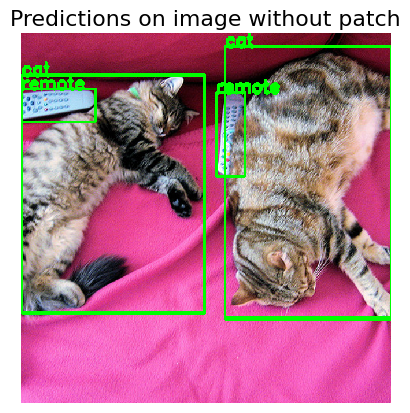

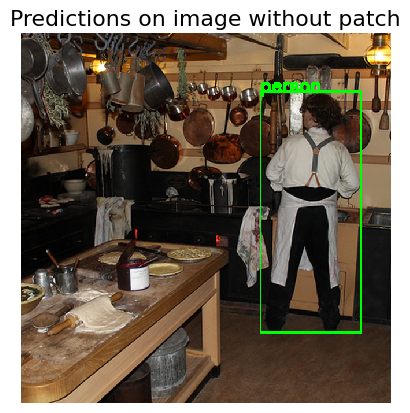

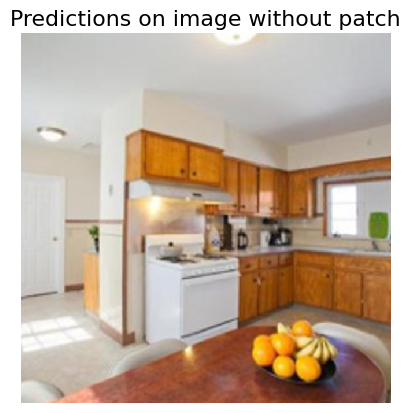

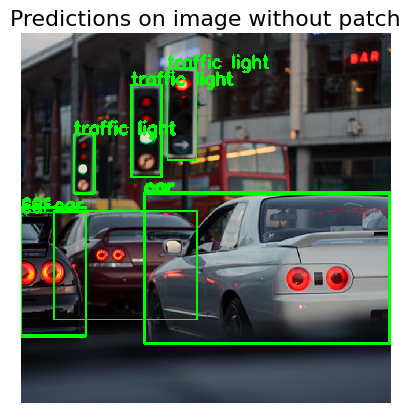

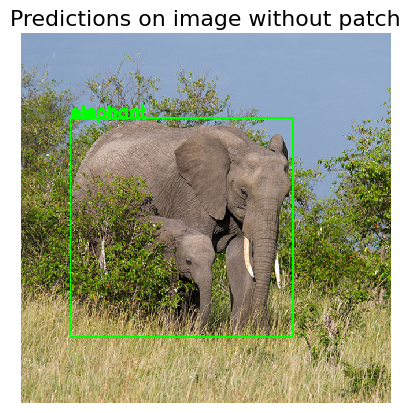

In [7]:
%matplotlib inline
dets = detector.predict(coco_images) 
for i in range(len(dets)):
    preds_orig = extract_predictions(dets[i], 0.8)
    plot_image_with_boxes(img=coco_images[i].transpose(1,2,0).copy(), boxes=preds_orig[1], pred_cls=preds_orig[0], title="Predictions on image without patch")

In [8]:
# adversarial patch generation

In [9]:
def filter_boxes(predictions, conf_thresh):
    dictionary = {}

    boxes_list = []
    scores_list = []
    labels_list = []

    for i in range(len(predictions[0]["boxes"])):
        score = predictions[0]["scores"][i]
        if score >= conf_thresh:
            boxes_list.append(predictions[0]["boxes"][i])
            scores_list.append(predictions[0]["scores"][[i]])
            labels_list.append(predictions[0]["labels"][[i]])

    if len(boxes_list)>0 and len(scores_list)>0 and len(labels_list)>0:
        dictionary["boxes"] = np.vstack(boxes_list)
        dictionary["scores"] = np.hstack(scores_list)
        dictionary["labels"] = np.hstack(labels_list)

    y = [dictionary]

    return y

y = [filter_boxes([t], 0.8)[0] for t in dets]

In [15]:

#TODO - make it work from here downwards
from advsecurenet.computer_vision.object_detection.attacks.adversarial_patch_based.dpatch import DPatchAttackConfig
config = DPatchAttackConfig(
    object_detector=detector,
    patch_shape=(3, 200, 200),
    learning_rate=learning_rate,
    max_iter=1000,
    batch_size=batch_size,
    verbose=True,
)
ap = DPatch(config)

res = ap.attack(x=coco_images[:-1], y=[y[-1] for i in range(len(coco_images[:-1]))], target_label=18, model=model, mask=None)
patch = res[0], res[1]

AttributeError: 'numpy.ndarray' object has no attribute 'detach'

In [ ]:
patched_images = ap.apply_patch(coco_images[:-1])
dets = detector.predict(patched_images)
for i in range(len(dets)):
    preds_orig = extract_predictions(dets[i], 0.5)
    plot_image_with_boxes(img=patched_images[i].transpose(1,2,0).copy(), boxes=preds_orig[1], pred_cls=preds_orig[0],
                           title="Predictions on image with patch")